# 05. Cell Composition / Deconvolution

This notebook reproduces the legacy `02_deconvolution.py` analysis inside the current revision pipeline.

It performs three cell-composition sensitivity analyses on the mRNA expression data:

1. **NNLS** regression against a curated binary signature matrix of 11 cord-blood cell types.
2. **Mean marker z-score** per cell type.
3. **Simplified ssGSEA score** using the normalized mean rank of marker genes.

Within-pair T1–T2 comparisons use the **exact paired Wilcoxon signed-rank test**, matching the legacy script.

> With only 3 twin pairs, the minimum attainable exact two-sided Wilcoxon P-value is 0.25. Therefore this analysis is descriptive/sensitivity-oriented rather than confirmatory.


In [6]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import nnls
from scipy import stats
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd.parents[1] if cwd.name == "revision" else cwd
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from config import *
from reproducibility import seed_everything

seed_everything()

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures" / "cell_composition"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("MRNA_DATA2   =", MRNA_DATA2)
print("SAMPLE_METADATA =", SAMPLE_METADATA)


PROJECT_ROOT = /Users/jihopark/Desktop/MCDA_revision_final
MRNA_DATA2   = /Users/jihopark/Desktop/MCDA_revision_final/data/processed/mRNA/data2.xlsx
SAMPLE_METADATA = /Users/jihopark/Desktop/MCDA_revision_final/data/metadata/sample_metadata.csv


## 1. Cell-type marker signature

In [7]:
SIGNATURE = {
    'T cells CD4': ['CD3D','CD3E','CD4','IL7R','LEF1','TCF7','CD27','CD28','LCK','ITK'],
    'T cells CD8': ['CD3D','CD3E','CD8A','CD8B','GZMK','EOMES','CCL5','NKG7','PRF1','GZMA'],
    'Treg': ['FOXP3','IL2RA','CTLA4','IKZF2','TNFRSF18','CD3D','CD3E','CD4'],
    'B cells': ['CD19','MS4A1','CD79A','CD79B','BLK','BANK1','PAX5','TCL1A','IGHM','IGHD'],
    'NK cells': ['NCAM1','KLRD1','NKG7','GNLY','GZMB','PRF1','KLRB1','KLRF1','FCGR3A','NCR1'],
    'Monocytes': ['CD14','CD68','LYZ','S100A8','S100A9','FCN1','VCAN','CSF1R','ITGAM','CST3'],
    'Neutrophils': ['FCGR3B','CEACAM8','CSF3R','CXCR1','CXCR2','S100A12','MMP9','CAMP','LCN2','AQP9'],
    'Erythroid': ['GYPA','HBB','HBA1','HBA2','ALAS2','SLC4A1','ANK1','EPB42','GATA1','KLF1'],
    'HSC/Progenitor': ['CD34','KIT','FLT3','HOXA9','MEIS1','GATA2','RUNX1','MPL','THY1','PROM1'],
    'pDC': ['IL3RA','CLEC4C','IRF7','TCF4','LILRA4','JCHAIN','GZMB','ITM2C','PLD4','SERPINF1'],
    'mDC': ['CD1C','ITGAX','FCER1A','CLEC10A','HLA-DQA1','HLA-DPA1','BATF3','IRF4','CD1E','THBD'],
}

CELL_TYPES = list(SIGNATURE.keys())

print("Cell types:", len(CELL_TYPES))
for ct, genes in SIGNATURE.items():
    print(f"{ct:16s}: {len(genes)} markers")


Cell types: 11
T cells CD4     : 10 markers
T cells CD8     : 10 markers
Treg            : 8 markers
B cells         : 10 markers
NK cells        : 10 markers
Monocytes       : 10 markers
Neutrophils     : 10 markers
Erythroid       : 10 markers
HSC/Progenitor  : 10 markers
pDC             : 10 markers
mDC             : 10 markers


## 2. Reconstruct the mRNA expression matrix from Macrogen `data2.xlsx`

In [8]:
meta = pd.read_csv(SAMPLE_METADATA)

sample_map = {}
samples = []

for _, row in meta.iterrows():
    pair = str(row["pair_id"]).strip()
    t1 = str(row["T1"]).strip()
    t2 = str(row["T2"]).strip()

    sample_map[f"N_{t1}"] = f"{pair}-T1"
    sample_map[f"N_{t2}"] = f"{pair}-T2"

    samples.extend([f"{pair}-T1", f"{pair}-T2"])

print("Analysis samples:", samples)

data2 = pd.read_excel(MRNA_DATA2)

required = {"Gene_Symbol", *sample_map.keys()}
missing = required - set(data2.columns)

if missing:
    raise ValueError(
        f"mRNA data2.xlsx missing required columns: {sorted(missing)}"
    )

expr = data2[["Gene_Symbol", *sample_map.keys()]].copy()
expr = expr.rename(columns=sample_map)

expr["Gene_Symbol"] = (
    expr["Gene_Symbol"]
    .fillna("")
    .astype(str)
    .str.strip()
)

expr = expr[expr["Gene_Symbol"] != ""].copy()

for s in samples:
    expr[s] = pd.to_numeric(expr[s], errors="coerce")

expr = expr.dropna(subset=samples, how="all")

# Match legacy 02_deconvolution.py:
# duplicate gene symbols are collapsed by sample-wise maximum.
df_gene = (
    expr.groupby("Gene_Symbol", as_index=False)[samples]
    .max()
)

print("Unique genes:", len(df_gene))
display(df_gene.head())


Analysis samples: ['MZ1-T1', 'MZ1-T2', 'MZ2-T1', 'MZ2-T2', 'MZ3-T1', 'MZ3-T2']
Unique genes: 29383


,Gene_Symbol,MZ1-T1,MZ1-T2,MZ2-T1,MZ2-T2,MZ3-T1,MZ3-T2
0,A1BG,2.33203,2.11667,2.36965,2.77371,2.90311,2.34183
1,A1BG-AS1,2.74724,2.78601,2.87251,3.05156,2.75949,2.85546
2,A1CF,1.11341,0.64576,0.77123,0.72017,0.89755,0.74732
3,A2M,1.23274,1.51221,1.27039,1.17590,1.26672,1.13628
4,A2M-AS1,2.68807,2.41070,2.31955,2.29548,2.65748,2.46440


## 3. Check signature-gene coverage

In [9]:
all_sig = set(
    gene
    for genes in SIGNATURE.values()
    for gene in genes
)

available_genes = set(df_gene["Gene_Symbol"])
sig_found = sorted(all_sig & available_genes)

print(
    f"Signature genes found: {len(sig_found)}/{len(all_sig)}"
)

coverage_rows = []

for ct, genes in SIGNATURE.items():
    found = sorted(set(genes) & available_genes)
    coverage_rows.append({
        "Cell_type": ct,
        "n_markers_defined": len(genes),
        "n_markers_found": len(found),
        "markers_found": ";".join(found),
    })

coverage = pd.DataFrame(coverage_rows)
display(coverage)


Signature genes found: 99/100


,Cell_type,n_markers_defined,n_markers_found,markers_found
0,T cells CD4,10,10,CD27;CD28;CD3D;CD3E;CD4;IL7R;ITK;LCK;LEF1;TCF7
1,T cells CD8,10,10,CCL5;CD3D;CD3E;CD8A;CD8B;EOMES;GZMA;GZMK;NKG7;...
2,Treg,8,8,CD3D;CD3E;CD4;CTLA4;FOXP3;IKZF2;IL2RA;TNFRSF18
3,B cells,10,10,BANK1;BLK;CD19;CD79A;CD79B;IGHD;IGHM;MS4A1;PAX...
4,NK cells,10,10,FCGR3A;GNLY;GZMB;KLRB1;KLRD1;KLRF1;NCAM1;NCR1;...
5,Monocytes,10,10,CD14;CD68;CSF1R;CST3;FCN1;ITGAM;LYZ;S100A8;S10...
6,Neutrophils,10,10,AQP9;CAMP;CEACAM8;CSF3R;CXCR1;CXCR2;FCGR3B;LCN...
7,Erythroid,10,10,ALAS2;ANK1;EPB42;GATA1;GYPA;HBA1;HBA2;HBB;KLF1...
8,HSC/Progenitor,10,9,CD34;FLT3;GATA2;KIT;MEIS1;MPL;PROM1;RUNX1;THY1
9,pDC,10,10,CLEC4C;GZMB;IL3RA;IRF7;ITM2C;JCHAIN;LILRA4;PLD...


## 4. Method 1 — NNLS estimated proportions

In [10]:
S = np.array([
    [
        1.0 if gene in SIGNATURE[ct] else 0.0
        for ct in CELL_TYPES
    ]
    for gene in sig_found
])

expr_sig = (
    df_gene[df_gene["Gene_Symbol"].isin(sig_found)]
    .set_index("Gene_Symbol")
    .loc[sig_found, samples]
)

props = {}

# The legacy script standardized S inside each loop;
# mathematically it is constant, so we compute it once here.
S_std = (
    S - S.mean(axis=0)
) / (
    S.std(axis=0) + 1e-10
)

for sample in samples:

    b = expr_sig[sample].values
    b_std = (
        b - b.mean()
    ) / (
        b.std() + 1e-10
    )

    weights, _ = nnls(
        S_std,
        b_std
    )

    proportions = (
        weights /
        (weights.sum() + 1e-10) *
        100
    )

    props[sample] = dict(
        zip(CELL_TYPES, proportions)
    )

prop_df = (
    pd.DataFrame(props)
    .T
    .round(2)
)

display(prop_df)


,T cells CD4,T cells CD8,Treg,B cells,NK cells,Monocytes,Neutrophils,Erythroid,HSC/Progenitor,pDC,mDC
MZ1-T1,11.22,0.92,0.0,10.18,0.00,24.17,12.93,39.61,0.0,0.00,0.96
MZ1-T2,12.41,1.80,0.0,10.41,0.00,24.31,10.02,40.68,0.0,0.00,0.37
MZ2-T1,9.82,0.00,0.0,11.94,2.56,24.31,11.51,39.86,0.0,0.00,0.00
MZ2-T2,9.46,1.11,0.0,13.42,0.00,24.41,11.89,38.37,0.0,0.00,1.35
MZ3-T1,12.99,1.12,0.0,11.50,2.00,21.79,9.67,40.02,0.0,0.00,0.92
MZ3-T2,12.51,2.71,0.0,11.34,1.32,22.30,9.95,39.87,0.0,0.01,0.00


## 5. Methods 2 and 3 — Marker z-score and simplified ssGSEA

In [11]:
expr_all = (
    df_gene
    .set_index("Gene_Symbol")[samples]
)

marker = {}
ssgsea = {}

ranks = {
    sample:
    stats.rankdata(expr_all[sample].values) / len(expr_all)
    for sample in samples
}

for sample in samples:

    values = expr_all[sample].values
    mu = values.mean()
    sigma = values.std()

    marker[sample] = {}
    ssgsea[sample] = {}

    for ct, genes in SIGNATURE.items():

        available = [
            g for g in genes
            if g in expr_all.index
        ]

        if not available:
            marker[sample][ct] = np.nan
            ssgsea[sample][ct] = np.nan
            continue

        idx = expr_all.index.get_indexer(available)

        marker[sample][ct] = float(
            (
                (
                    expr_all.loc[available, sample].values
                    - mu
                )
                /
                (sigma + 1e-10)
            ).mean()
        )

        ssgsea[sample][ct] = float(
            ranks[sample][idx].mean()
        )

marker_df = (
    pd.DataFrame(marker)
    .T
    .round(4)
)

ssgsea_df = (
    pd.DataFrame(ssgsea)
    .T
    .round(4)
)

print("Marker z-scores")
display(marker_df)

print("Simplified ssGSEA scores")
display(ssgsea_df)


Marker z-scores


,T cells CD4,T cells CD8,Treg,B cells,NK cells,Monocytes,Neutrophils,Erythroid,HSC/Progenitor,pDC,mDC
MZ1-T1,1.1793,0.4053,0.3478,1.0644,0.1255,2.3780,1.3229,3.8289,-0.1794,0.0630,0.1985
MZ1-T2,1.3499,0.5622,0.4317,1.1313,0.1440,2.4215,1.0948,3.9411,0.0376,0.1113,0.1994
MZ2-T1,1.0818,0.4102,0.3260,1.2748,0.4208,2.4004,1.2357,3.8162,0.0938,0.1044,0.1843
MZ2-T2,0.9960,0.3698,0.2269,1.3455,0.0862,2.3754,1.2025,3.6831,-0.0195,-0.0098,0.2151
MZ3-T1,1.4210,0.5509,0.4838,1.2577,0.3697,2.2415,1.0822,3.9847,-0.0225,0.1386,0.2451
MZ3-T2,1.4016,0.6711,0.4350,1.2361,0.3220,2.2935,1.1025,3.9885,-0.0670,0.1563,0.1181


Simplified ssGSEA scores


,T cells CD4,T cells CD8,Treg,B cells,NK cells,Monocytes,Neutrophils,Erythroid,HSC/Progenitor,pDC,mDC
MZ1-T1,0.8370,0.6754,0.6843,0.8236,0.5726,0.9455,0.8287,0.9652,0.5121,0.5826,0.5911
MZ1-T2,0.8738,0.7260,0.7094,0.8353,0.5775,0.9511,0.8104,0.9700,0.6029,0.6068,0.6062
MZ2-T1,0.8349,0.6738,0.6851,0.8443,0.6821,0.9419,0.8271,0.9668,0.6296,0.6008,0.5908
MZ2-T2,0.8229,0.6587,0.6541,0.8525,0.5559,0.9482,0.8097,0.9575,0.5815,0.5598,0.5882
MZ3-T1,0.8803,0.7282,0.7418,0.8397,0.6708,0.9410,0.8036,0.9693,0.5957,0.6248,0.6305
MZ3-T2,0.8790,0.7576,0.7160,0.8350,0.6590,0.9430,0.8248,0.9671,0.5778,0.6350,0.5880


## 6. Exact paired Wilcoxon comparison

In [12]:
PAIRS = meta["pair_id"].astype(str).tolist()

def within_pair_stats(score_df, value_label):

    rows = []

    for ct in CELL_TYPES:

        t1 = np.array([
            score_df.loc[f"{pair}-T1", ct]
            for pair in PAIRS
        ])

        t2 = np.array([
            score_df.loc[f"{pair}-T2", ct]
            for pair in PAIRS
        ])

        diff = t1 - t2

        if np.allclose(diff, 0):
            p_value = 1.0
        else:
            p_value = stats.wilcoxon(
                t1,
                t2,
                zero_method="wilcox",
                mode="exact"
            ).pvalue

        rows.append({
            "Cell Type": ct,
            f"Mean T1 ({value_label})": t1.mean(),
            f"Mean T2 ({value_label})": t2.mean(),
            "Mean diff T1-T2": diff.mean(),
            "diff_MZ1": diff[0],
            "diff_MZ2": diff[1],
            "diff_MZ3": diff[2],
            "Wilcoxon exact P": p_value,
            "3-pair consistent": bool(
                np.all(diff > 0)
                or np.all(diff < 0)
            ),
        })

    return pd.DataFrame(rows)


res_nnls = within_pair_stats(
    prop_df,
    "%"
)

res_marker = within_pair_stats(
    marker_df,
    "z"
)

res_ssgsea = within_pair_stats(
    ssgsea_df,
    "rank"
)

print("NNLS")
display(res_nnls)

print("Marker z-score")
display(res_marker)

print("ssGSEA")
display(res_ssgsea)

print(
    "Minimum attainable exact two-sided P with n=3 pairs: 0.25"
)


NNLS


,Cell Type,Mean T1 (%),Mean T2 (%),Mean diff T1-T2,diff_MZ1,diff_MZ2,diff_MZ3,Wilcoxon exact P,3-pair consistent
0,T cells CD4,11.343333,11.460000,-0.116667,-1.19,0.36,0.48,1.00,False
1,T cells CD8,0.680000,1.873333,-1.193333,-0.88,-1.11,-1.59,0.25,True
2,Treg,0.000000,0.000000,0.000000,0.00,0.00,0.00,1.00,False
3,B cells,11.206667,11.723333,-0.516667,-0.23,-1.48,0.16,0.50,False
4,NK cells,1.520000,0.440000,1.080000,0.00,2.56,0.68,0.50,False
5,Monocytes,23.423333,23.673333,-0.250000,-0.14,-0.10,-0.51,0.25,True
6,Neutrophils,11.370000,10.620000,0.750000,2.91,-0.38,-0.28,1.00,False
7,Erythroid,39.830000,39.640000,0.190000,-1.07,1.49,0.15,0.75,False
8,HSC/Progenitor,0.000000,0.000000,0.000000,0.00,0.00,0.00,1.00,False
9,pDC,0.000000,0.003333,-0.003333,0.00,0.00,-0.01,1.00,False


Marker z-score


,Cell Type,Mean T1 (z),Mean T2 (z),Mean diff T1-T2,diff_MZ1,diff_MZ2,diff_MZ3,Wilcoxon exact P,3-pair consistent
0,T cells CD4,1.227367,1.249167,-0.021800,-0.1706,0.0858,0.0194,1.00,False
1,T cells CD8,0.455467,0.534367,-0.078900,-0.1569,0.0404,-0.1202,0.50,False
2,Treg,0.385867,0.364533,0.021333,-0.0839,0.0991,0.0488,0.75,False
3,B cells,1.198967,1.237633,-0.038667,-0.0669,-0.0707,0.0216,0.50,False
4,NK cells,0.305333,0.184067,0.121267,-0.0185,0.3346,0.0477,0.50,False
5,Monocytes,2.339967,2.363467,-0.023500,-0.0435,0.0250,-0.0520,0.50,False
6,Neutrophils,1.213600,1.133267,0.080333,0.2281,0.0332,-0.0203,0.50,False
7,Erythroid,3.876600,3.870900,0.005700,-0.1122,0.1331,-0.0038,1.00,False
8,HSC/Progenitor,-0.036033,-0.016300,-0.019733,-0.2170,0.1133,0.0445,1.00,False
9,pDC,0.102000,0.085933,0.016067,-0.0483,0.1142,-0.0177,1.00,False


ssGSEA


,Cell Type,Mean T1 (rank),Mean T2 (rank),Mean diff T1-T2,diff_MZ1,diff_MZ2,diff_MZ3,Wilcoxon exact P,3-pair consistent
0,T cells CD4,0.850733,0.858567,-0.007833,-0.0368,0.0120,0.0013,1.00,False
1,T cells CD8,0.692467,0.714100,-0.021633,-0.0506,0.0151,-0.0294,0.50,False
2,Treg,0.703733,0.693167,0.010567,-0.0251,0.0310,0.0258,0.50,False
3,B cells,0.835867,0.840933,-0.005067,-0.0117,-0.0082,0.0047,0.50,False
4,NK cells,0.641833,0.597467,0.044367,-0.0049,0.1262,0.0118,0.50,False
5,Monocytes,0.942800,0.947433,-0.004633,-0.0056,-0.0063,-0.0020,0.25,True
6,Neutrophils,0.819800,0.814967,0.004833,0.0183,0.0174,-0.0212,1.00,False
7,Erythroid,0.967100,0.964867,0.002233,-0.0048,0.0093,0.0022,0.75,False
8,HSC/Progenitor,0.579133,0.587400,-0.008267,-0.0908,0.0481,0.0179,1.00,False
9,pDC,0.602733,0.600533,0.002200,-0.0242,0.0410,-0.0102,1.00,False


Minimum attainable exact two-sided P with n=3 pairs: 0.25


## 7. Cross-method summary

In [13]:
method_summary = pd.DataFrame([
    {
        "Method": "NNLS",
        "n_cell_types": len(res_nnls),
        "n_P_lt_0_05": int((res_nnls["Wilcoxon exact P"] < 0.05).sum()),
        "min_P": res_nnls["Wilcoxon exact P"].min(),
        "n_3pair_consistent": int(res_nnls["3-pair consistent"].sum()),
    },
    {
        "Method": "Marker z-score",
        "n_cell_types": len(res_marker),
        "n_P_lt_0_05": int((res_marker["Wilcoxon exact P"] < 0.05).sum()),
        "min_P": res_marker["Wilcoxon exact P"].min(),
        "n_3pair_consistent": int(res_marker["3-pair consistent"].sum()),
    },
    {
        "Method": "ssGSEA",
        "n_cell_types": len(res_ssgsea),
        "n_P_lt_0_05": int((res_ssgsea["Wilcoxon exact P"] < 0.05).sum()),
        "min_P": res_ssgsea["Wilcoxon exact P"].min(),
        "n_3pair_consistent": int(res_ssgsea["3-pair consistent"].sum()),
    },
])

display(method_summary)


,Method,n_cell_types,n_P_lt_0_05,min_P,n_3pair_consistent
0,NNLS,11,0,0.25,2
1,Marker z-score,11,0,0.50,0
2,ssGSEA,11,0,0.25,1


## 8. Paired NNLS visualization

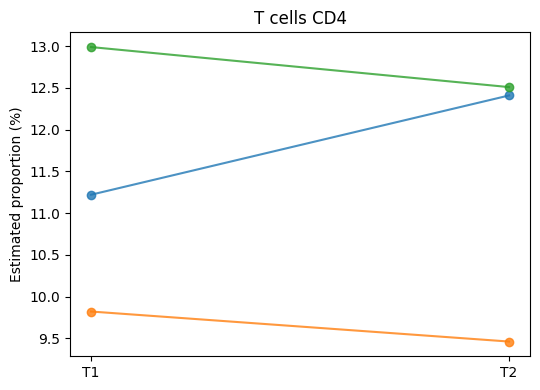

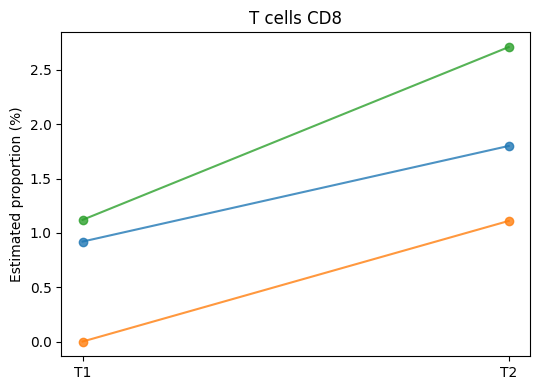

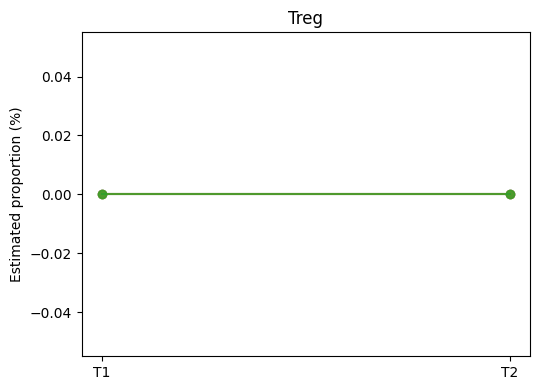

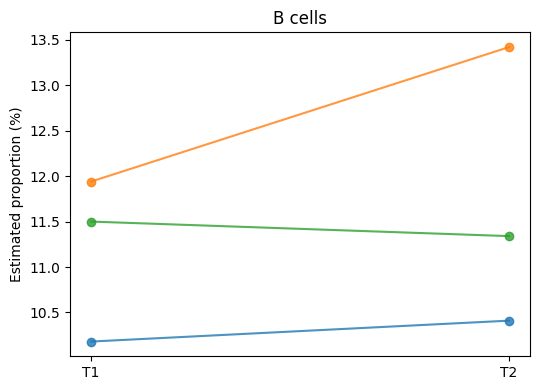

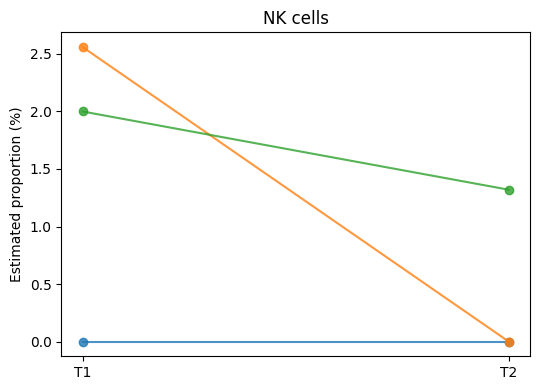

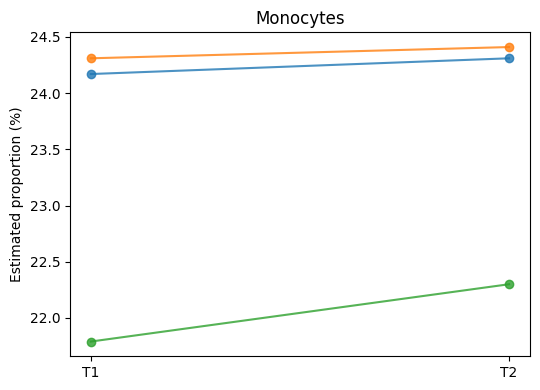

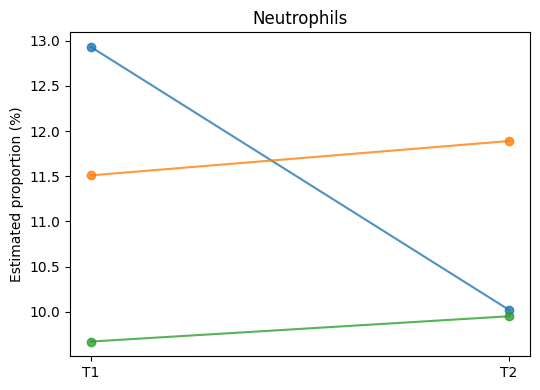

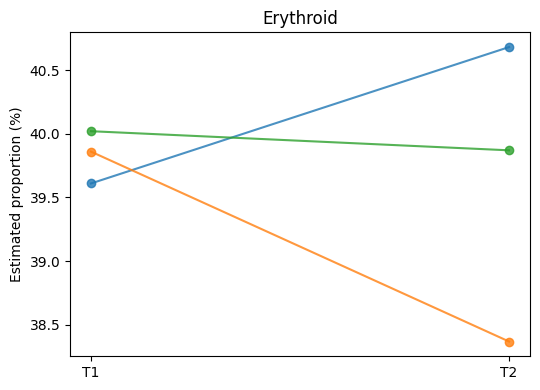

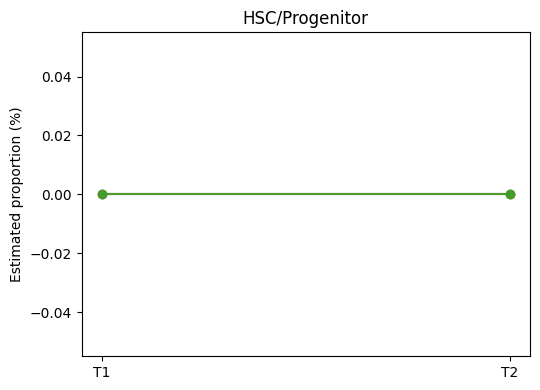

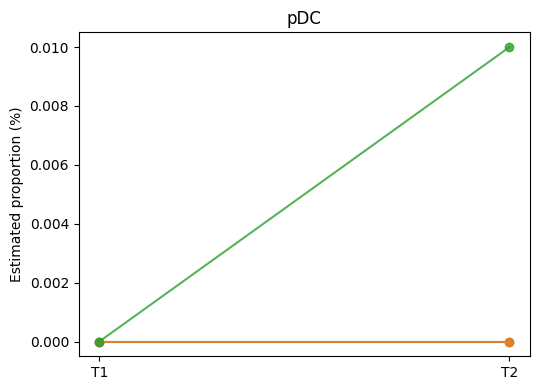

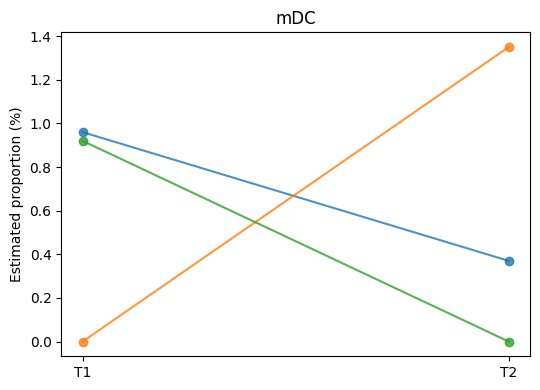

In [14]:
for ct in CELL_TYPES:

    fig, ax = plt.subplots(figsize=(5.5, 4))

    for pair in PAIRS:
        y = [
            prop_df.loc[f"{pair}-T1", ct],
            prop_df.loc[f"{pair}-T2", ct],
        ]
        ax.plot(
            ["T1", "T2"],
            y,
            marker="o",
            alpha=0.8
        )

    ax.set_ylabel("Estimated proportion (%)")
    ax.set_title(ct)
    fig.tight_layout()

    safe = (
        ct.lower()
        .replace("/", "_")
        .replace(" ", "_")
    )

    fig.savefig(
        FIGURES_DIR / f"05_nnls_{safe}.png",
        dpi=300
    )

    plt.show()


## 9. Save deconvolution outputs

In [15]:
coverage.to_csv(
    RESULTS_DIR / "deconvolution_signature_coverage.csv",
    index=False
)

prop_df.to_csv(
    RESULTS_DIR / "deconvolution_NNLS_proportions.csv"
)

marker_df.to_csv(
    RESULTS_DIR / "deconvolution_marker_zscores.csv"
)

ssgsea_df.to_csv(
    RESULTS_DIR / "deconvolution_ssgsea_scores.csv"
)

res_nnls.to_csv(
    RESULTS_DIR / "deconvolution_within_pair_stats_NNLS.csv",
    index=False
)

res_marker.to_csv(
    RESULTS_DIR / "deconvolution_within_pair_stats_marker.csv",
    index=False
)

res_ssgsea.to_csv(
    RESULTS_DIR / "deconvolution_within_pair_stats_ssgsea.csv",
    index=False
)

method_summary.to_csv(
    RESULTS_DIR / "deconvolution_method_summary.csv",
    index=False
)

with pd.ExcelWriter(
    RESULTS_DIR / "deconvolution_summary.xlsx"
) as writer:

    coverage.to_excel(
        writer,
        sheet_name="Signature coverage",
        index=False
    )

    prop_df.to_excel(
        writer,
        sheet_name="NNLS proportions"
    )

    marker_df.to_excel(
        writer,
        sheet_name="Marker z-scores"
    )

    ssgsea_df.to_excel(
        writer,
        sheet_name="ssGSEA scores"
    )

    res_nnls.to_excel(
        writer,
        sheet_name="NNLS stats",
        index=False
    )

    res_marker.to_excel(
        writer,
        sheet_name="Marker stats",
        index=False
    )

    res_ssgsea.to_excel(
        writer,
        sheet_name="ssGSEA stats",
        index=False
    )

    method_summary.to_excel(
        writer,
        sheet_name="Method summary",
        index=False
    )

print("Deconvolution outputs saved to:")
print(RESULTS_DIR)


Deconvolution outputs saved to:
/Users/jihopark/Desktop/MCDA_revision_final/results


## Interpretation

This deconvolution analysis is a **sensitivity analysis for potential cellular-composition confounding**.

The legacy analysis estimates cell composition using NNLS, marker z-scores, and simplified ssGSEA scores, and compares T1 versus T2 using an exact paired Wilcoxon signed-rank test.

Because only three twin pairs are available, the analysis has very limited inferential power. The appropriate conclusion is therefore whether there is **evidence of a consistent, large T1–T2 composition shift**, not that cell composition has been definitively ruled out as a confounder.

The reviewer specifically questioned the use of a classical Student t-test for deconvolution results. This notebook reproduces the legacy revision script's paired exact Wilcoxon analysis instead of a Student t-test. The estimated NNLS values are continuous model-derived proportions rather than observed cell counts, so count-based chi-square/Fisher tests are not directly interchangeable with this analysis.
